# Credit Card Fraud Detection Using Machine Learning

## Project Overview

This project focuses on detecting fraudulent credit card transactions using machine learning techniques.

The dataset contains transaction information and a binary target variable indicating whether a transaction is legitimate or fraudulent.

The project covers data cleaning, exploratory data analysis, class imbalance handling using SMOTE, model training, evaluation, and comparison of Logistic Regression and Random Forest classifiers.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Imbalanced-learn (SMOTE)

### Machine Learning Models

1. Logistic Regression
2. Random Forest Classifier

In [1]:
!pip install imbalanced-learn -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


## 1. Dataset Loading and Initial Inspection

The Credit Card Fraud Detection dataset contains 284,807 transactions and 31 columns. It contains transaction-related features, including Time, Amount, anonymized features V1 to V28, and the Class column.

The Class column is the target variable. A value of 0 represents a legitimate transaction, while a value of 1 represents a fraudulent transaction.

In the next step, we will inspect the column names, data types, missing values, and duplicate records.

In [4]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print("Dataset successfully loaded!")
print("Rows and Columns:", df.shape)

Dataset successfully loaded!
Rows and Columns: (284807, 31)


In [5]:
# Check column names
print("Column Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Missing Values:
0

Duplicate Rows:
1081


## 2. Data Quality Assessment

The dataset contains 31 columns, and the features are stored as numerical data types, which makes the dataset suitable for machine learning analysis.

There are no missing values in the dataset, so no missing-value imputation is required.

However, 1,081 duplicate rows were identified. These duplicate records may cause repeated observations to have more influence during model training. Therefore, the duplicate rows will be removed before building the machine learning models.

The `Class` column is stored as an integer and will be used as the target variable, where 0 represents legitimate transactions and 1 represents fraudulent transactions.

In [26]:
# Count duplicates before removing them
duplicate_count = df.duplicated().sum()

print("Duplicate rows before cleaning:", duplicate_count)

# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("New dataset shape:", df.shape)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
New dataset shape: (283726, 31)


### Duplicate Removal — Observation

A total of 1,081 duplicate rows were identified in the original dataset. These duplicate records were removed to prevent repeated observations from influencing the machine learning models.

After removing the duplicates, the dataset contains 283,726 unique transaction records and no duplicate rows.

In [27]:
# Count legitimate and fraudulent transactions
class_counts = df["Class"].value_counts()

print("Normal transactions:", class_counts[0])
print("Fraudulent transactions:", class_counts[1])

print("\nPercentage of each class:")
print((class_counts / len(df) * 100).round(4))

Normal transactions: 283253
Fraudulent transactions: 473

Percentage of each class:
Class
0    99.8333
1     0.1667
Name: count, dtype: float64


### Class Distribution — Observation

After removing duplicate records, the dataset contains 283,253 legitimate transactions and 473 fraudulent transactions.

Legitimate transactions account for 99.8333% of the dataset, while fraudulent transactions account for only 0.1667%.

This shows a severe class imbalance. Since fraudulent transactions are extremely rare compared with legitimate transactions, accuracy alone would be misleading. For example, a model could predict almost every transaction as legitimate and still achieve very high accuracy while failing to detect fraud.

Therefore, we will focus on Precision, Recall, F1-Score and ROC-AUC when evaluating our machine learning models. We will also use SMOTE to address the class imbalance in the training data.






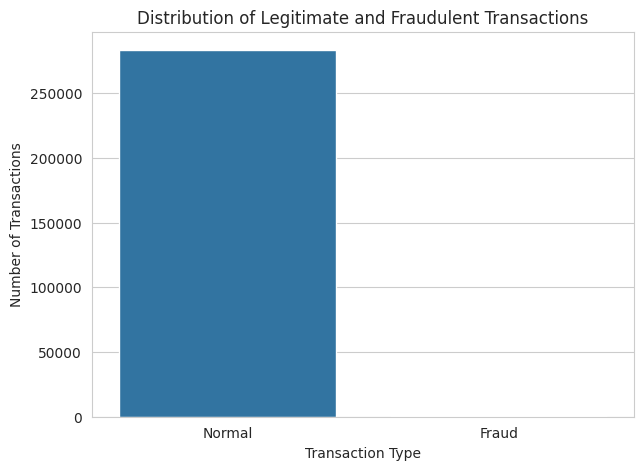

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(x="Class", data=df)

plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks([0, 1], ["Normal", "Fraud"])

plt.show()

### Visualization Observation

The bar chart clearly shows the severe imbalance between legitimate and fraudulent transactions. The legitimate transaction bar is substantially larger than the fraudulent transaction bar.

This visualization confirms that fraud detection is an imbalanced classification problem. To prevent the model from being biased toward the majority class, we will apply an appropriate class-imbalance handling technique during model training.

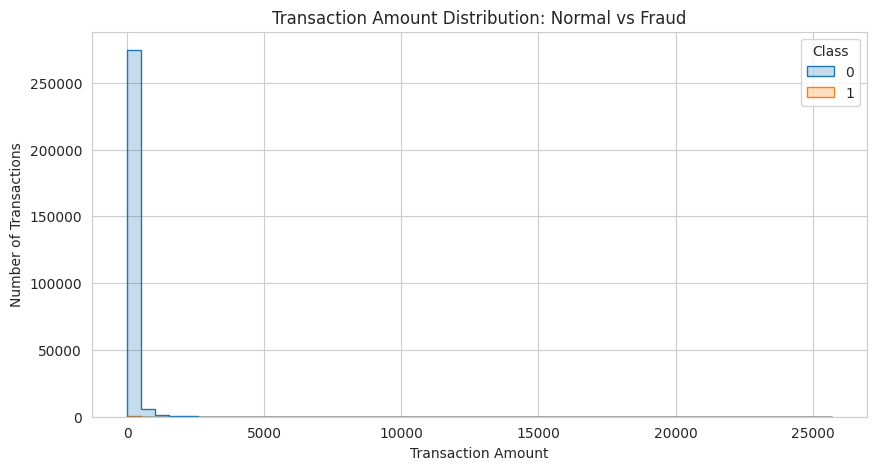

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    element="step"
)

plt.title("Transaction Amount Distribution: Normal vs Fraud")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

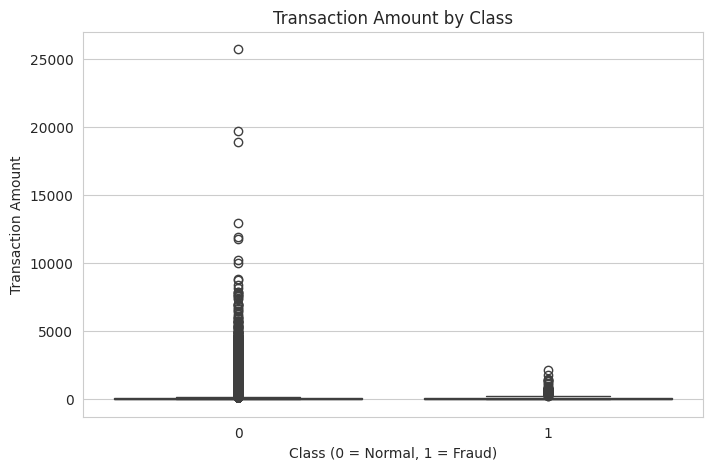

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

**Graph 1: Transaction Amount Distribution: Normal vs FraudObservation:**
From the histogram, it is clear that the majority of transactions, both normal and fraudulent, have a very low transaction amount, mostly below 1000. The distribution is highly right-skewed. Fraud transactions are extremely rare compared to normal transactions. The count of normal transactions is in lakhs, while fraud transactions are barely visible. This shows extreme class imbalance in the dataset.

**Graph 2: Transaction Amount by ClassObservation:**
The boxplot shows that for both normal class 0 and fraud class 1, most transaction amounts are close to zero with many outliers. However, fraud transactions have a few very high-value outliers, going above 25000. Normal transactions also have outliers but the spread is wider. The median transaction amount for both classes is almost zero. This indicates that transaction amount alone cannot clearly separate fraud from normal transactions, and we need to use other features for better classification.

### Transaction Amount Analysis — Observation

The transaction amount distributions show how transaction values differ between legitimate and fraudulent transactions. The box plot also helps identify the spread and presence of extreme transaction amounts.

Transaction amount can be useful for fraud detection, but it should not be considered alone. The anonymized V1–V28 features may contain additional patterns that help distinguish fraudulent transactions from legitimate ones.

In [31]:
# Separate features and target variable

X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


### Feature and Target Separation

For machine learning, the dataset was divided into input features and the target variable.

The `Class` column was selected as the target because it indicates whether a transaction is legitimate or fraudulent. The remaining 30 columns were used as input features.

Therefore, `X` contains the transaction features and `y` contains the fraud labels.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nFraud cases in training set:", y_train.sum())
print("Fraud cases in testing set:", y_test.sum())

Training samples: 226980
Testing samples: 56746

Fraud cases in training set: 378
Fraud cases in testing set: 95


### Train-Test Split — Observation

The cleaned dataset was divided into training and testing sets using an 80:20 split. The training set contains 226,980 transactions, while the testing set contains 56,746 transactions.

Stratified splitting was used to ensure that fraudulent transactions were represented in both datasets. There are 378 fraudulent transactions in the training set and 95 fraudulent transactions in the testing set.

The test set will be kept separate and will only be used to evaluate the final machine learning models.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed!
Training data shape: (226980, 30)
Testing data shape: (56746, 30)


### Feature Scaling — Observation

Feature scaling was applied using StandardScaler so that the numerical features have a comparable scale.

The scaler was fitted only on the training data and then applied to both the training and testing data. This prevents information from the test set from leaking into the training process.

Scaling is particularly important for distance-based and linear machine learning algorithms such as Logistic Regression.

In [34]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


### SMOTE — Observation

The dataset has a severe class imbalance, with legitimate transactions greatly outnumbering fraudulent transactions.

SMOTE (Synthetic Minority Over-sampling Technique) was applied only to the training data. It creates synthetic examples of the minority fraud class to provide a more balanced training dataset.

The test data was not oversampled because it should retain the original class distribution for realistic model evaluation.

In [35]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_smote, y_train_smote)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Logistic Regression — Model Training

Logistic Regression was selected as the first classification model because it is a simple, interpretable and computationally efficient algorithm for binary classification.

The model was trained using the SMOTE-balanced training dataset. The target variable contains two classes: legitimate transactions (0) and fraudulent transactions (1).

The original test dataset will be used to evaluate how well the model performs on unseen transactions.

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Predict on the ORIGINAL test data
y_pred_lr = logistic_model.predict(X_test_scaled)

# Probability of fraud
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------
Accuracy  : 0.9737
Precision : 0.0530
Recall    : 0.8737
F1-Score  : 0.1000
ROC-AUC   : 0.9626

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



### Logistic Regression — Evaluation Results

The Logistic Regression model achieved an accuracy of 97.37% and a ROC-AUC score of 96.26%.

The model achieved a recall of 87.37% for fraudulent transactions, meaning that it successfully detected most of the actual fraud cases in the test set.

However, the precision for the fraud class was only 5.30%. This means that many transactions predicted as fraudulent were actually legitimate transactions. This creates a high number of false positives.

Therefore, accuracy alone is not an appropriate metric for this highly imbalanced fraud detection problem. Recall is important because missing fraudulent transactions can be costly, but precision must also be considered because excessive false alarms can inconvenience legitimate customers.

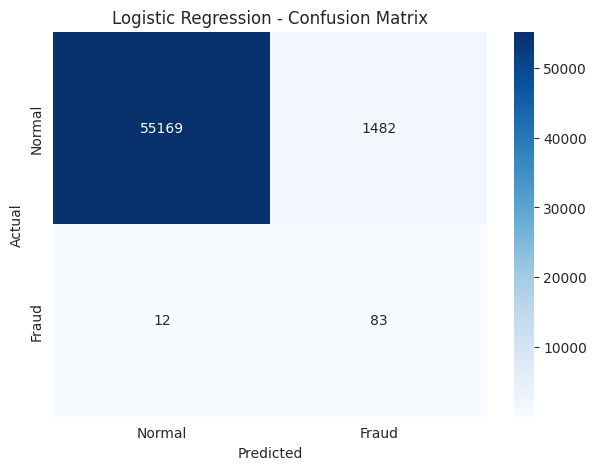

In [37]:
# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix — Observation

The confusion matrix shows how the Logistic Regression model classified the test transactions.

The model successfully identified most fraudulent transactions, which is consistent with its high recall of 87.37%. However, a number of legitimate transactions were incorrectly classified as fraudulent, resulting in false positives.

This confirms the trade-off between detecting more fraud cases and reducing false alarms. In a real-world fraud detection system, this trade-off must be carefully managed.

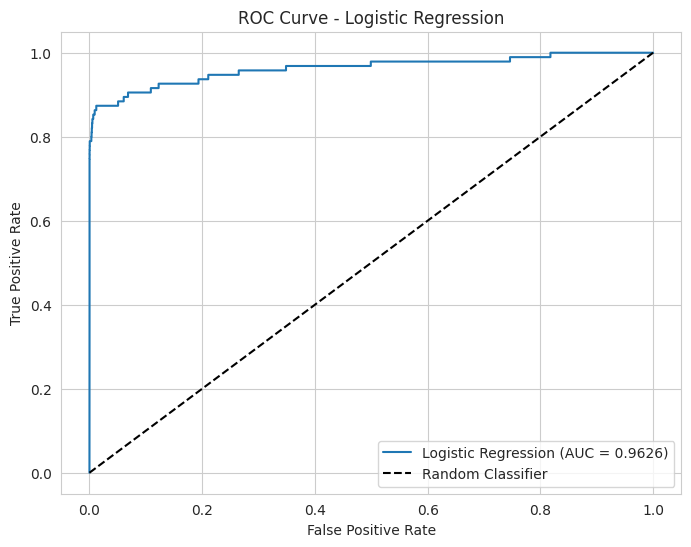

In [38]:
# Calculate ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_lr:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train_smote, y_train_smote)

print("Random Forest model trained successfully!")

### Random Forest — Model Training

Random Forest was selected as the second classification model because it can capture complex and non-linear relationships between transaction features.

The model was trained using the SMOTE-balanced training dataset. Random Forest uses multiple decision trees and combines their predictions to improve classification performance.

The model will be evaluated on the original unseen test dataset using Precision, Recall, F1-Score and ROC-AUC.

In [ ]:
# Predict on the original test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Probability of fraud
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

### Random Forest — Evaluation Results

The Random Forest model achieved an accuracy of 99.95%, precision of 91.25%, recall of 76.84%, F1-score of 83.43%, and ROC-AUC of 96.94%.

Compared with Logistic Regression, Random Forest produced a much higher precision and F1-score. This means that it generated considerably fewer false-positive fraud alerts while maintaining a good ability to detect fraudulent transactions.

Although Logistic Regression achieved a higher recall of 87.37%, its precision was only 5.30%. Therefore, Random Forest provides a better overall balance between detecting fraud and avoiding unnecessary alerts.

Based on these results, Random Forest is currently the stronger candidate for deployment, although the final choice should depend on the business cost of missed fraud versus false alerts.

In [ ]:
# Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Random Forest Confusion Matrix — Observation

The confusion matrix shows that the Random Forest model correctly classified the vast majority of transactions.

The model produced fewer false-positive predictions than Logistic Regression, which is consistent with its much higher precision of 91.25%.

However, some fraudulent transactions were still classified as legitimate. These false negatives are important in fraud detection because they represent fraud cases that the system failed to identify.

In [ ]:
# Calculate ROC curve for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

### Random Forest ROC-AUC — Observation

The Random Forest model achieved a ROC-AUC score of 0.9694. The ROC curve remains well above the random classifier baseline, indicating that the model has a strong ability to distinguish fraudulent transactions from legitimate transactions.

The ROC-AUC score is slightly higher than the Logistic Regression score of 0.9626.

In [ ]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

### Feature Importance — Observation

The Random Forest feature importance analysis identifies the features that contributed most to the model's predictions.

The importance scores show that some anonymized transaction features have a stronger influence on fraud classification than others. These features can help the model distinguish fraudulent transactions from legitimate transactions.

Because V1 to V28 are anonymized features, their business meaning cannot be directly interpreted. However, their relative importance can still be used to understand which variables are most useful for prediction.

In [ ]:
# Compare both models

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_lr, accuracy_rf],
    "Precision": [precision_lr, precision_rf],
    "Recall": [recall_lr, recall_rf],
    "F1-Score": [f1_lr, f1_rf],
    "ROC-AUC": [roc_auc_lr, roc_auc_rf]
})

model_comparison.round(4)

### Model Comparison — Observation

The two classification models show different strengths.

Logistic Regression achieved a higher recall of 87.37%, meaning it detected a larger proportion of fraudulent transactions. However, its precision was only 5.30%, resulting in a large number of false-positive alerts.

Random Forest achieved a much higher precision of 91.25% and F1-score of 83.43%, while maintaining a strong recall of 76.84%. It also achieved a slightly higher ROC-AUC score of 96.94%.

Overall, Random Forest provides a better balance between fraud detection and false-positive reduction and is therefore the preferred model for this project.

## 8. Scalability Considerations

A production fraud detection system may need to process a very large number of transactions in real time.

For approximately 1 million transactions per hour, the model could be deployed as a real-time machine learning service behind an API. Transactions could be processed in batches or through a streaming system depending on latency requirements.

The Random Forest model can be optimized by controlling the number and depth of trees, using parallel processing, and reducing unnecessary features. For very high-volume systems, a lightweight model or distributed machine learning infrastructure may be preferred.

The production system should also include continuous monitoring for model performance, data drift, changes in fraud patterns, and false-positive rates. The model should periodically be retrained using recent transaction data.

# 9. Conclusion

This project developed a machine learning pipeline for detecting fraudulent credit card transactions.

The dataset was cleaned by removing 1,081 duplicate records. Exploratory analysis showed severe class imbalance, with fraudulent transactions representing only 0.1667% of the cleaned dataset. SMOTE was therefore applied to the training data to improve the model's ability to learn the minority fraud class.

Two classification models were trained and evaluated: Logistic Regression and Random Forest.

Logistic Regression achieved a recall of 87.37%, which means it detected most fraudulent transactions, but its precision was only 5.30%, resulting in many false-positive alerts.

Random Forest achieved 99.95% accuracy, 91.25% precision, 76.84% recall, 83.43% F1-score, and 96.94% ROC-AUC. It provided a much better balance between detecting fraud and reducing false alerts.

Based on the evaluation results, Random Forest was selected as the preferred model for this project.

### Business Recommendations

1. Deploy Random Forest as the primary fraud detection model because it provides a strong balance between fraud detection and false-positive reduction.

2. Monitor recall and false-negative transactions continuously because missed fraudulent transactions can result in financial losses.

3. Monitor false-positive rates and periodically retrain the model using recent transaction data to adapt to changing fraud patterns.

4. Use real-time monitoring and scalable infrastructure when deploying the model in a high-volume transaction environment.

## 10. Project Summary

### Key Findings

- The dataset contained severe class imbalance, with fraudulent transactions representing only 0.1667% of the cleaned dataset.
- 1,081 duplicate records were removed during data cleaning.
- SMOTE was applied only to the training data to address class imbalance.
- Logistic Regression achieved high fraud recall (87.37%) but produced many false-positive predictions.
- Random Forest achieved a strong balance between precision (91.25%) and recall (76.84%), with an F1-score of 83.43% and ROC-AUC of 96.94%.
- Based on the overall evaluation, Random Forest was selected as the preferred model.

### Final Recommendation

Random Forest is recommended as the primary model for this fraud detection task. However, the model should be continuously monitored and retrained with recent transaction data because fraud patterns can change over time.